In [ ]:
# Se importan las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') 

In [ ]:
traffic.head() # se muestran las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head() # se muestran las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [ ]:
# Se examina la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [ ]:
# Se examina la estructura de eco
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas'City GDP/capita', 'Unemployment %', 'PM2.5 (μg/m³)', 'Population (M)' deberían ser floats en vez de strings de acuerdo a nuestro diccionario del dataset 2

In [ ]:
# Estandarizo nombres de columnas en traffic

traffic = traffic.rename(columns = {'Country':'country', 'UpdateTimeUTC':'update_time_utc', 'City':'city','JamsDelay': 'jams_delay', 'TrafficIndexLive':'traffic_index_live', 'JamsLengthInKms':'jams_length_kms', 'JamsCount':'jams_count', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins', 'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins', 'MinsDelay':'mins_delay'}) 


# verifico cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizo nombres de columnas en eco

eco = eco.rename(columns = {'Year':'year', 'City':'city', 'Country':'country', 'City GDP/capita': 'city_gdp_capita', 'Unemployment %': 'unemployment_pct', 'PM2.5 (μg/m³)': 'pm25', 'Population (M)':'population_m'}) 


# verifico cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

In [ ]:
# Se convierten las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors = 'coerce') 
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors = 'coerce') 

# verifico el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [ ]:
# Limpio separadores y convierto columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.','').str.replace(',','.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%','').str.replace(',','.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',','.').astype(float)
# Calculo la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

 # verifico el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


In [ ]:

# Extraigo el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
traffic_2024 = traffic[traffic['year'] == 2024]
# Verifico cambio
traffic.head(3)


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtro los registros del año 2024
eco_2024 = eco[eco['year'] == 2024].copy()

traffic_2024= traffic_2024.copy()
eco_2024 = eco_2024.copy()

# Reviso dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


In [ ]:
# Calcule los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city','country','year'])[['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins']].mean().reset_index() 
# Muestro el resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
# Muestro las ciudades con mayor retraso por congestión en 2024
display(traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)
)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es ciudad de mexico; ordenando de mayor a menor segun la columna, jams_delay. Me parece sorprendente, la verdad esperaba que fuera otra ciudad de asia por las demas columnas


In [ ]:
# Selecciono las columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']
traffic_2024_small= traffic_city_year_2024[['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']].copy() 
eco_2024_small= eco_2024[['city','year','city_gdp_capita','unemployment_pct','pm25','population']].copy()


 # Unifique los datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city','year'], how='inner') 

merged.head() # Muestro las primeras 5 filas


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


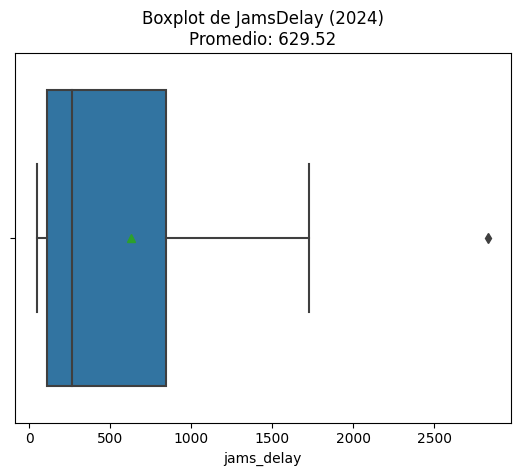

In [ ]:
# Cree boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, x='jams_delay', showmeans = True)
# Obtuve promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


<AxesSubplot:xlabel='city_gdp_capita', ylabel='Count'>

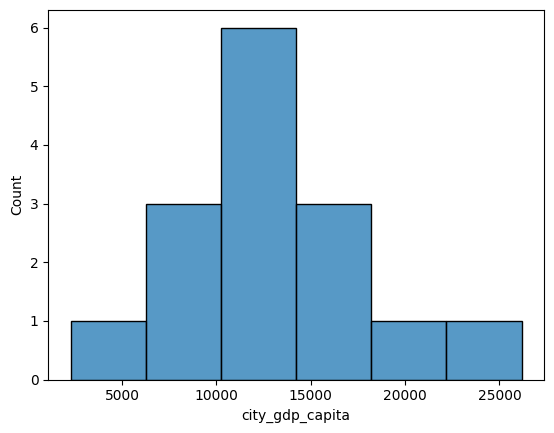

In [ ]:
sns.histplot(data=merged, x='city_gdp_capita') # Cree el histograma para ver la distribución de la economía (city_gdp_capita)



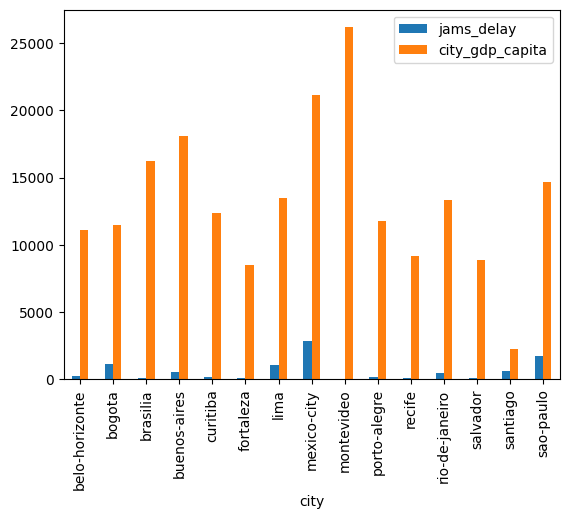

In [ ]:

merged.plot(
    x='city',
    y=['jams_delay','city_gdp_capita'],
    kind='bar'
)
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad

plt.xticks(rotation=90)
plt.show()


* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

1. No necesariamente, las ciudades con una gran congestión presentan un gran PIB, pero tengo la hipótesis de que depende de su número de metros cuadrados y cantidad de habitantes
2.  Entonces, existe una tendencia que a mayor congestión sea más probable que su PIB sea alto, pero no siempre se cumple como lo podemos evidenciar en varias ciudades de Brasil


In [ ]:

# Exporte el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)



# 🧾 Resumen ejecutivo 

**Contexto & objetivo:**  
- la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?

 - se tomaron ambas columnas jams_delay(congestión) y city_gdp_capita(PIB per cápita), se hizo una comparativa por ciudad para el año 2024 con los datos que coincidían en año y ciudad, donde encontramos que varias ciudades con alta congestión tienen un PIB per cápita por encima del promedio sin embargo no es totalmente proporcional a su movilidad

   
- las variables clave utilizadas y su relevancia para la toma de decisiones.

 - jams_delay → Retraso promedio causado por la congestión vehicular.
city_gdp_capita → PIB per cápita de la ciudad.
city → Nombre de la ciudad.
country → País al que pertenece la ciudad.
year → Año del registro analizado (2024).
population → Población total estimada de la ciudad.

**Cobertura de datos:**  

- Año analizado fue 2024, un total de 15 ciudades y 7 paises
 
**Metodología (alto nivel):**  
 
 - Primero, evidenciamos una visión general de cada archivo con .info(), luego identificamos los errores de formato, valores nulos, nombres de las variables, cantidad de datos y las columnas relevantes para nuestro análisis. Comenzamos con la estandarización tipo snake_case para ambos datasets, luego cambiamos el formato según date, float o string correspondiente, reemplazamos y eliminamos comas, puntos y porcentajes
   
- En este paso agrupamos por ciudad, país, año. Con la restricción de incluir datos con solo columnas en común entre ambos datasets, para poder hacer la comparativa original
   
- Para comenzar hicimos un boxplot para jams_delay(congestión) para evidenciar la mediana, el promedio, valores min, max, cuartiles, outliers y su respectiva distribución, luego realizamos un histograma, con el PIB per cápita para evidenciar la cantidad de ciudades que se ubican en la cantidad de PIB analizado    

**Hallazgos iniciales:**  

- Evidenciamos que por índices de tráfico tenemos un promedio de 629.52, la mediana de 350, debido a un valor máximo atípico de 2833.06 por parte de Ciudad de México, un mínimo de 50.20 por parte de Montevideo que curiosamente tiene el mayor PIB per cápita, los patrones para PIB per cápita  contienen un outlier min muy extremo, desde la base de datos; Santiago de Chile con tan solo 2277.0 en comparacion con su periodo pasado disminuyo un 90% lo cual es poco probable, se recomienda verificar la fuente de datos para corroborar, el PIB promedio de los paises fue de 13253.6, donde 6 de las 15 ciudades se ubican entre 10,000 y 15,000.  
 
 

**Recomendaciones**  

- Ciudades prioritarias: Ciudad de México tiene el segundo PIB más alto, junto con la mayor congestión de las ciudades. Con una inversión en transporte alternativo, como la movilidad eléctrica, o una mejor distribución en el horario laboral, podrían generar aún más. Lo mismo sucede con São Paulo y Bogotá, que están por encima del promedio de congestión: podrían incrementar significativamente su rentabilidad anual con estrategias como el trabajo desde casa o híbrido. 
La necesidad de validar fuentes sería trascendental: revisar los outliers de ambas categorías; en Ciudad de México, para corroborar el número de jams_delay(congestion), ya que es demasiado alto; y, para el PIB per cápita, revisar Santiago de Chile por su reducción tan significativa con respecto al año pasado. Análisis adicionales podrían incluir cantidad de metros cuadrados y habitantes por país, ya que esto también refleja un problema de tráfico menor, como sucede en Montevideo. Propuestas de inversión y estrategias incluyen, infraestructura, prioridad en semáforos por horas para ciertas vías, trabajo desde casa o híbrido, movilidad eléctrica, cambios de horario en horas con menor congestión.  
   




In [ ]:
#conteo unico para paises y ciudades
merged['country'].nunique()
merged['city'].nunique()

7

In [ ]:
# Muestro las ciudades con mayor retraso por congestión en 2024
jams_per_city = merged.groupby('city')['jams_delay'].mean().sort_values(ascending = False)
display(jams_per)

city
mexico-city       2833.06
sao-paulo         1729.19
bogota            1141.55
lima              1052.29
santiago           629.87
buenos-aires       571.09
rio-de-janeiro     466.06
belo-horizonte     263.05
curitiba           183.47
porto-alegre       139.38
recife             112.76
brasilia           101.58
salvador            86.40
fortaleza           82.81
montevideo          50.20
Name: jams_delay, dtype: float64

In [ ]:
# Muestro las ciudades con mayor PIB per cápita en 2024
PIB_per_city = merged.groupby('city')['city_gdp_capita'].mean().sort_values(ascending = False)
display(PIB_per_city)

city
montevideo        26176.0
mexico-city       21111.0
buenos-aires      18117.0
brasilia          16251.0
sao-paulo         14703.0
lima              13472.0
rio-de-janeiro    13349.0
curitiba          12381.0
porto-alegre      11801.0
bogota            11442.0
belo-horizonte    11124.0
recife             9189.0
salvador           8899.0
fortaleza          8512.0
santiago           2277.0
Name: city_gdp_capita, dtype: float64

In [ ]:
# Muestro las estadísticas descriptivas para Santiago
merged[merged['city']=='santiago']['city_gdp_capita'].describe()


count       1.0
mean     2277.0
std         NaN
min      2277.0
25%      2277.0
50%      2277.0
75%      2277.0
max      2277.0
Name: city_gdp_capita, dtype: float64

In [ ]:
# Muestro las estadísticas descriptivas para Santiago
eco[eco['city'] == 'santiago']

,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
10,2023,santiago,Chile,22176.0,8.5,"22,80",7.0,7000000.0
25,2024,santiago,Chile,2277.0,7.8,"21,30",7.1,7100000.0


In [ ]:
# Muestro la validacion para Santiago
eco[eco['city'] == 'santiago'][['year', 'city_gdp_capita']]

,year,city_gdp_capita
10,2023,22176.0
25,2024,2277.0


In [ ]:
# Muestro el promedio de PIB per cápita para todas las ciudades
pib_avg = merged['city_gdp_capita'].mean()
print(pib_avg)

13253.6
